In [3]:
import os
import glob
import torch
import matplotlib.pyplot as plt
import polars as pl
import pyarrow.parquet as pq
import numpy as np

INPUT_PARQUET = "../protbert/datasets/dataset_merged_with_families.parquet"


In [12]:

# ==========================================
# 1. PŘÍPRAVA DAT
# ==========================================
# Zde simulujeme načtení tvého CSV souboru pomocí textového řetězce (pro ukázku).
# V praxi tento blok smažeš a nahradíš ho tímto:
# df = pd.read_csv("tvuj_dataset.csv")

DEDUP_PARQUET = "deduplicated_dataset.parquet"

df = pl.read_parquet(INPUT_PARQUET).select(["original_seq_full"]).unique()

#  write async for saving ram an load just original seqence to memory
df.write_parquet(DEDUP_PARQUET)





In [4]:
# get list of not reverse proteins


OUT = "noreverse.parquet"
df = pl.read_parquet(INPUT_PARQUET).filter(pl.col("reverse") == False).select(["original_seq_full"]).unique()


df.write_parquet(OUT)


📂 Načítám data z final_clusters.parquet...
🎉 Celkem nalezeno clusterů: 17
🗑️ Počet proteinů v šumu (cluster -1): 52 (5.49 %)

Top 10 největších rodin:
shape: (10, 2)
┌────────────┬─────┐
│ cluster_id ┆ len │
│ ---        ┆ --- │
│ i64        ┆ u32 │
╞════════════╪═════╡
│ 7          ┆ 338 │
│ 1          ┆ 70  │
│ 6          ┆ 59  │
│ 0          ┆ 50  │
│ 4          ┆ 43  │
│ 13         ┆ 40  │
│ 16         ┆ 36  │
│ 8          ┆ 33  │
│ 12         ┆ 33  │
│ 2          ┆ 32  │
└────────────┴─────┘
🔄 Převádím embeddingy na matici...
✨ Počítám 2D UMAP pro vizualizaci...


/home/jvlk/miniforge3/envs/protbert/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Hotovo.


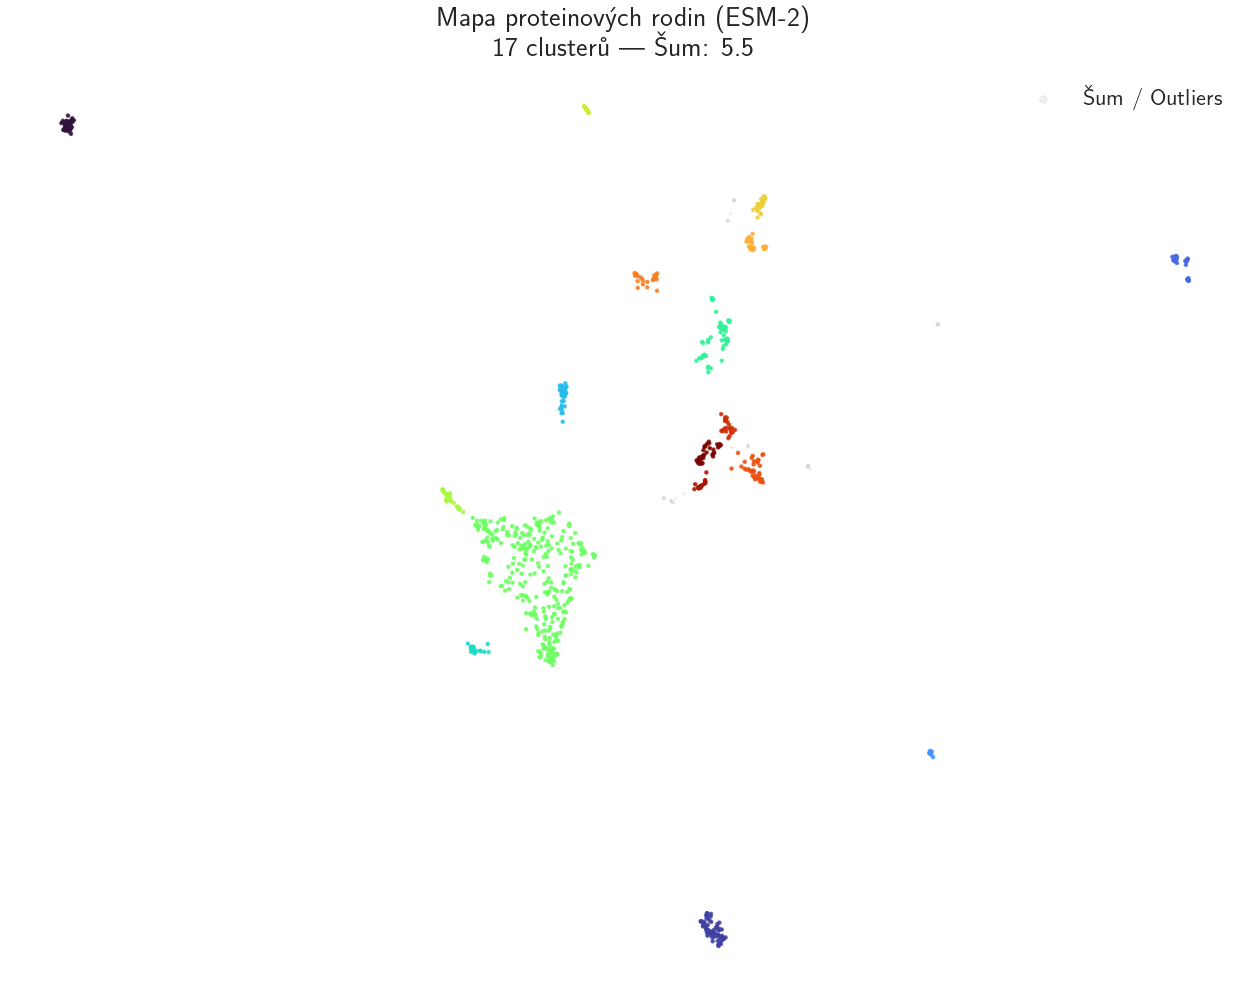

In [4]:
import polars as pl
import numpy as np

import seaborn as sns
import umap
import plotly.express as px

# Nastavení pro hezčí grafy
sns.set(style="white", context="talk")
%matplotlib inline

# %%
INPUT_FILE = "final_clusters.parquet"  # <-- ZDE UPRAVTE CESTU

print(f"📂 Načítám data z {INPUT_FILE}...")
df = pl.read_parquet(INPUT_FILE)

# %%
# Počet unikátních clusterů (bez šumu -1)
n_clusters = df["cluster_id"].n_unique() - (1 if -1 in df["cluster_id"] else 0)
n_noise = df.filter(pl.col("cluster_id") == -1).height
noise_percent = (n_noise / len(df)) * 100

print(f"🎉 Celkem nalezeno clusterů: {n_clusters}")
print(f"🗑️ Počet proteinů v šumu (cluster -1): {n_noise} ({noise_percent:.2f} %)")

# Top 10 největších clusterů
top_clusters = df.filter(pl.col("cluster_id") != -1).group_by("cluster_id").len().sort("len", descending=True).head(10)
print("\nTop 10 největších rodin:")
print(top_clusters)

if "embedding" in df.columns:
    print("🔄 Převádím embeddingy na matici...")
    X = np.stack(df["embedding"].to_numpy())

    print("✨ Počítám 2D UMAP pro vizualizaci...")
    # Používáme stejnou metriku jako při clusteringu
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42, n_jobs=-1)
    embedding_2d = reducer.fit_transform(X)

    # Přidáme souřadnice do DataFrame
    df = df.with_columns([
        pl.Series("umap_x", embedding_2d[:, 0]),
        pl.Series("umap_y", embedding_2d[:, 1])
    ])
    print("✅ Hotovo.")
else:
    print("❌ CHYBA: Sloupec 'embedding' chybí! Nemohu vypočítat souřadnice pro graf.")

# %%


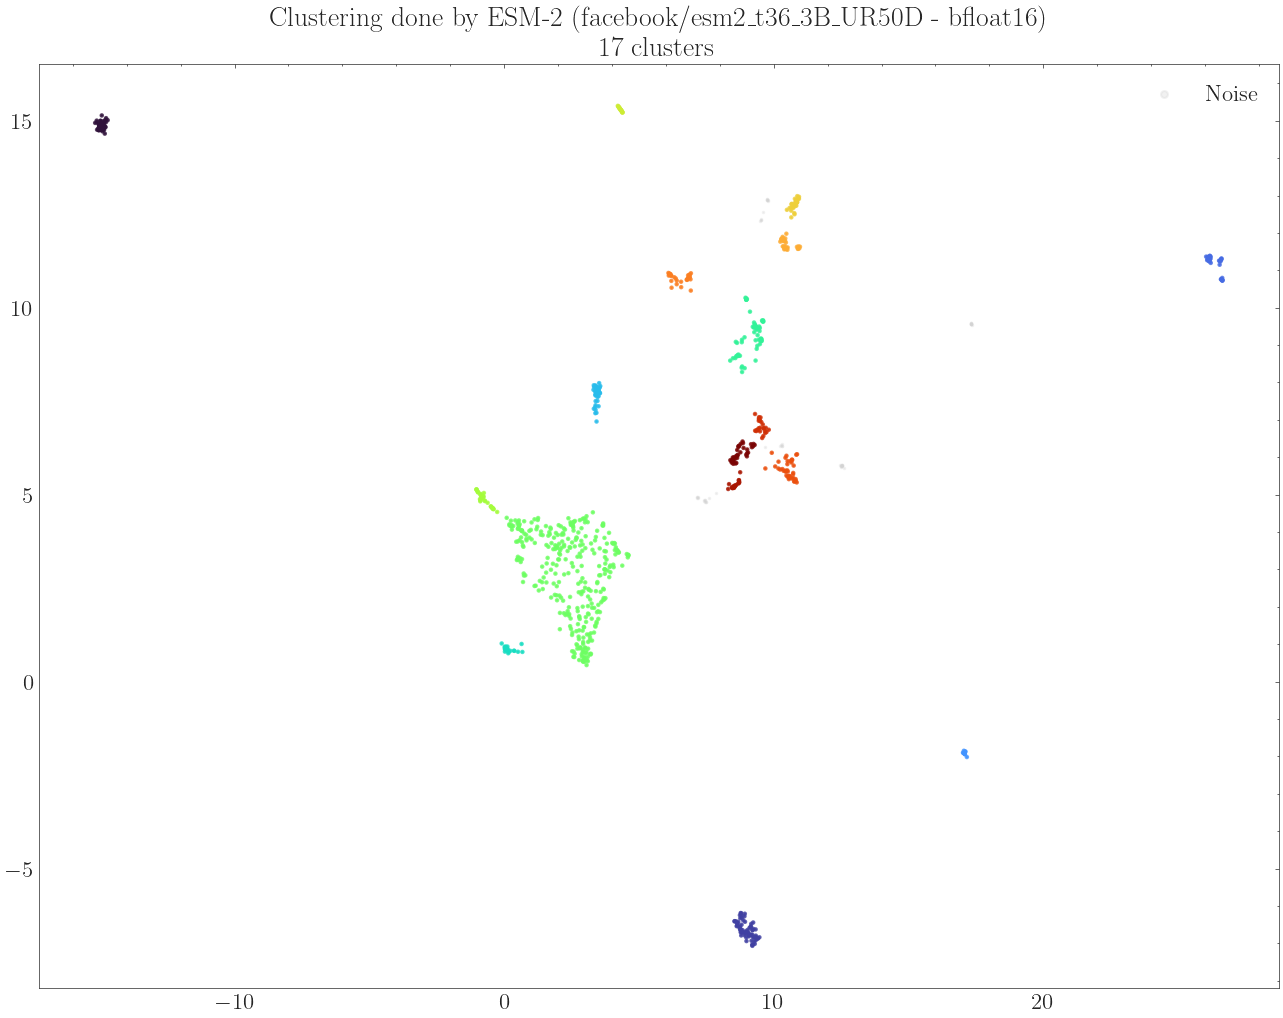

In [10]:

import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')

plt.figure(figsize=(16, 12))

# 1. Vykreslení šumu (šedě)
noise_data = df.filter(pl.col("cluster_id") == -1)
if len(noise_data) > 0:
    plt.scatter(noise_data["umap_x"], noise_data["umap_y"],
                c='lightgrey', s=1, alpha=0.3, label='Noise')

# 2. Vykreslení clusterů (barevně)
# Použijeme 'turbo' paletu, která má hodně barev pro hodně clusterů
cluster_data = df.filter(pl.col("cluster_id") != -1)
scatter = plt.scatter(cluster_data["umap_x"], cluster_data["umap_y"],
                      c=cluster_data["cluster_id"], cmap='turbo', s=3, alpha=0.8)

plt.title(f"Clustering done by ESM-2 (facebook/esm2_t36_3B_UR50D - bfloat16)\n{n_clusters} clusters", fontsize=20)

plt.legend(markerscale=5, loc='upper right')

# Uložení
plt.savefig("protein_clusters_map.pdf", dpi=300, bbox_inches='tight')
plt.show()



In [2]:
MAX_POINTS = 50000
if len(df) > MAX_POINTS:
    print(f"⚠️ Dat je hodně, zobrazuji náhodný vzorek {MAX_POINTS} bodů pro plynulost.")
    df_plot = df.sample(n=MAX_POINTS, seed=42)
else:
    df_plot = df

# Převedeme na Pandas pro Plotly
df_pd = df_plot.to_pandas()

# Změníme cluster_id na string, aby se barvy braly jako kategorie (ne čísla)
df_pd["cluster_id"] = df_pd["cluster_id"].astype(str)

fig = px.scatter(
    df_pd,
    x="umap_x",
    y="umap_y",
    color="cluster_id",
    # Co se ukáže po najetí myší (upravte podle názvů sloupců ve vašem Parquetu)
    hover_data=["membership_prob", "cluster_id"],
    title=f"Interaktivní mapa proteinů ({n_clusters} rodin)",
    color_discrete_sequence=px.colors.qualitative.Dark24, # Paleta s mnoha barvami
    width=1200,
    height=800
)

# Zmenšení bodů a vypnutí os
fig.update_traces(marker=dict(size=3, opacity=0.7))
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
)

fig.show()


NameError: name 'df' is not defined